# Paychecks & Power: Unpacking the Salary Landscape of Washington, D.C.'s Public Workforce
**Trishma Garcon**

**MATH 014 — Introduction to Data Science**  
**Howard University | Spring 2026**  
**Dataset: DC Public Employee Salary — DC Open Data**

---


## 0 | Setup & Imports

In [55]:
# Standard data science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Visual settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlepad': 14
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1 | Load the Dataset

The DC Public Employee Salary dataset is available from the **DC Open Data Portal**:  
🔗 https://opendata.dc.gov/datasets/dc-public-employee-salary

**To use this notebook:**
1. Download the dataset as a CSV from the link above
2. Place it in the same folder as this notebook
3. Update `FILE_PATH` below to match the filename

Alternatively, the cell below will attempt to download it directly via the DC Open Data Socrata API.


In [56]:
import urllib.request
import os

# ── Option A: Load from local CSV ─────────────────────────────────────
FILE_PATH = "DC_Public_Employee_Salary.csv"   # ← update if filename differs

# ── Option B: Download from DC Open Data API (uncomment if needed) ────
# SOCRATA_URL = (
#     "https://opendata.dc.gov/api/explore/v2.1/catalog/datasets/"
#     "dc-public-employee-salary/exports/csv?lang=en&timezone=America%2FNew_York"
# )
# urllib.request.urlretrieve(SOCRATA_URL, FILE_PATH)
# print("Downloaded dataset successfully.")

# ── Load ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(FILE_PATH)
print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Dataset loaded: 40,611 rows × 9 columns


## 2 | Data Understanding

### 2.1 — First Look

In [57]:
# Preview the first few rows
df_raw.head(10)


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
5,James,Broughton,Program Monitor,DBH,12,107046.00,1987/10/01,CS - Reg,6
6,Gertrude,Allen,Program Support Assistant,DBH,07,67548.00,1990/12/03,CS - Reg,7
7,Karen,Bowie,Behavioral Health Technician,DBH,08,63711.00,2021/05/24,CS - Reg,8
8,Jeremy,Park,MEDICAL OFFICER PSYCH RES,DBH,00,70325.00,2025/07/01,CS - Temp,9
9,Richard,Gontang,Chief Clinical Officer,DBH,15,177839.89,1994/11/03,MSS - Reg,10


In [58]:
# Column names and data types
print("Column Names and Data Types")
print("=" * 45)
print(df_raw.dtypes)


Column Names and Data Types
FIRST_NAME           object
LAST_NAME            object
JOBTITLE             object
DESCRSHORT           object
GRADE                object
COMPRATE            float64
HIREDATE_STRING      object
GVT_TYPE_OF_APPT     object
OBJECTID              int64
dtype: object


In [59]:
# Shape and basic info
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")


Rows    : 40,611
Columns : 9


### 2.2 — Descriptive Statistics

In [60]:
# Descriptive statistics for all columns
df_raw.describe(include='all')


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
count,40611,40611,40611,40611,40571,40611.000000,40611,40611,40611.000000
unique,12930,15110,3698,88,68,NaN,4914,18,NaN
top,Michael,Williams,OFFICER,DCPS,15,NaN,2025/08/11,CS - Reg,NaN
freq,466,588,2027,11764,7376,NaN,402,19794,NaN
mean,NaN,NaN,NaN,NaN,NaN,89087.755572,NaN,NaN,20306.000000
std,NaN,NaN,NaN,NaN,NaN,47453.788915,NaN,NaN,11723.530228
min,NaN,NaN,NaN,NaN,NaN,0.030000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,66130.000000,NaN,NaN,10153.500000
50%,NaN,NaN,NaN,NaN,NaN,93234.000000,NaN,NaN,20306.000000
75%,NaN,NaN,NaN,NaN,NaN,119643.130000,NaN,NaN,30458.500000


### 2.3 — Missing Values

In [61]:
# Count of missing values per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])


       Missing Count  Missing %
GRADE             40        0.1


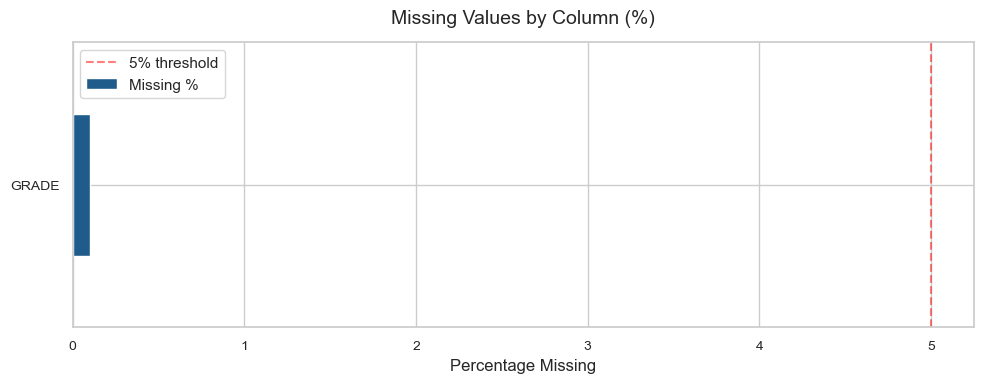

Figure saved.


In [62]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(10, 4))
missing_plot = missing_df[missing_df['Missing Count'] > 0]

if not missing_plot.empty:
    missing_plot['Missing %'].plot(kind='barh', ax=ax, color='#1F5C8B')
    ax.set_title('Missing Values by Column (%)')
    ax.set_xlabel('Percentage Missing')
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No missing values found!',
            ha='center', va='center', fontsize=13, transform=ax.transAxes)
    ax.set_title('Missing Values by Column')

plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 3 | Data Cleaning & Preprocessing

### 3.1 — Standardize Column Names

In [63]:
# Work on a copy to preserve the original
df = df_raw.copy()

# Standardize column names: lowercase, strip spaces, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

print("Standardized column names:")
for col in df.columns:
    print(f"  {col}")


Standardized column names:
  first_name
  last_name
  jobtitle
  descrshort
  grade
  comprate
  hiredate_string
  gvt_type_of_appt
  objectid


### 3.2 — Identify the Salary Column

In [64]:
# Identify the annual salary column (adjust if your dataset uses a different name)
# Common names: 'annual_salary', 'salary', 'annualsalary', 'base_salary', 'comprate'
salary_candidates = [c for c in df.columns if 'salary' in c or 'pay' in c or 'wage' in c or 'comp' in c]
print("Salary-related columns found:", salary_candidates)

# Set the primary salary column — update this if needed
SALARY_COL = salary_candidates[0] if salary_candidates else 'comprate'
print(f"\nUsing salary column: '{SALARY_COL}'")
print("Sample values:", df[SALARY_COL].head(5).tolist())


Salary-related columns found: ['comprate']

Using salary column: 'comprate'
Sample values: [123873.0, 115907.0, 122500.0, 41.73, 75787.0]


### 3.3 — Convert Salary to Numeric

In [65]:
# Remove dollar signs, commas, and spaces; convert to float
before_dtype = df[SALARY_COL].dtype

df[SALARY_COL] = (
    df[SALARY_COL]
    .astype(str)
    .str.replace(r'[$,\s]', '', regex=True)
    .str.strip()
)

# Replace empty strings and non-numeric placeholders with NaN
df[SALARY_COL] = pd.to_numeric(df[SALARY_COL], errors='coerce')

after_dtype = df[SALARY_COL].dtype
print(f"Salary column dtype: {before_dtype} → {after_dtype}")
print(f"Null values after conversion: {df[SALARY_COL].isnull().sum()}")


Salary column dtype: float64 → float64
Null values after conversion: 0


### 3.4 — Remove Invalid Salary Rows

In [66]:
initial_count = len(df)

# Drop rows where salary is null
df = df.dropna(subset=[SALARY_COL])

# Drop rows where salary is $0 or negative (likely data entry errors)
df = df[df[SALARY_COL] > 0]

removed = initial_count - len(df)
print(f"Rows before cleaning : {initial_count:,}")
print(f"Invalid rows removed : {removed:,}")
print(f"Rows after cleaning  : {len(df):,}")


Rows before cleaning : 40,611
Invalid rows removed : 0
Rows after cleaning  : 40,611


### 3.5 — Remove Duplicates

In [67]:
dupes_before = df.duplicated().sum()
df = df.drop_duplicates()
dupes_after = df.duplicated().sum()

print(f"Duplicate rows found and removed: {dupes_before:,}")
print(f"Remaining duplicates: {dupes_after}")
print(f"Final dataset size: {len(df):,} rows")


Duplicate rows found and removed: 0
Remaining duplicates: 0
Final dataset size: 40,611 rows


### 3.6 — Standardize Agency/Department Names

In [68]:
# Identify agency/department column
agency_candidates = [c for c in df.columns if 'agency' in c or 'department' in c or 'dept' in c or 'descr' in c]
print("Agency-related columns found:", agency_candidates)

AGENCY_COL = agency_candidates[0] if agency_candidates else 'descrshort'
print(f"\nUsing agency column: '{AGENCY_COL}'")

# Standardize: strip whitespace, title case
df[AGENCY_COL] = df[AGENCY_COL].astype(str).str.strip().str.title()

print(f"\nUnique agencies after standardization: {df[AGENCY_COL].nunique()}")
print("\nTop 10 agencies by employee count:")
print(df[AGENCY_COL].value_counts().head(10).to_string())



Agency-related columns found: ['descrshort']

Using agency column: 'descrshort'

Unique agencies after standardization: 88

Top 10 agencies by employee count:
descrshort
Dcps        11764
Mpd          4123
Fems         2366
Udc          1716
Dpw          1480
Ocfo         1386
Dbh          1248
Ddot         1212
Dhs          1182
Osse Dot     1177


### 3.7 — Cleaning Summary

In [69]:
print("=" * 50)
print("       DATA CLEANING SUMMARY")
print("=" * 50)
print(f"  Original rows           : {len(df_raw):,}")
print(f"  After removing nulls    : {len(df):,}")
print(f"  Salary column type      : {df[SALARY_COL].dtype}")
print(f"  Unique agencies         : {df[AGENCY_COL].nunique()}")
print(f"  Min salary              : ${df[SALARY_COL].min():,.2f}")
print(f"  Max salary              : ${df[SALARY_COL].max():,.2f}")
print(f"  Median salary           : ${df[SALARY_COL].median():,.2f}")
print(f"  Mean salary             : ${df[SALARY_COL].mean():,.2f}")
print("=" * 50)


       DATA CLEANING SUMMARY
  Original rows           : 40,611
  After removing nulls    : 40,611
  Salary column type      : float64
  Unique agencies         : 88
  Min salary              : $0.03
  Max salary              : $390,232.00
  Median salary           : $93,234.00
  Mean salary             : $89,087.76


## 4 | Exploratory Data Analysis

### Analysis Question 1
**What does the overall salary distribution look like across all DC public employees?**


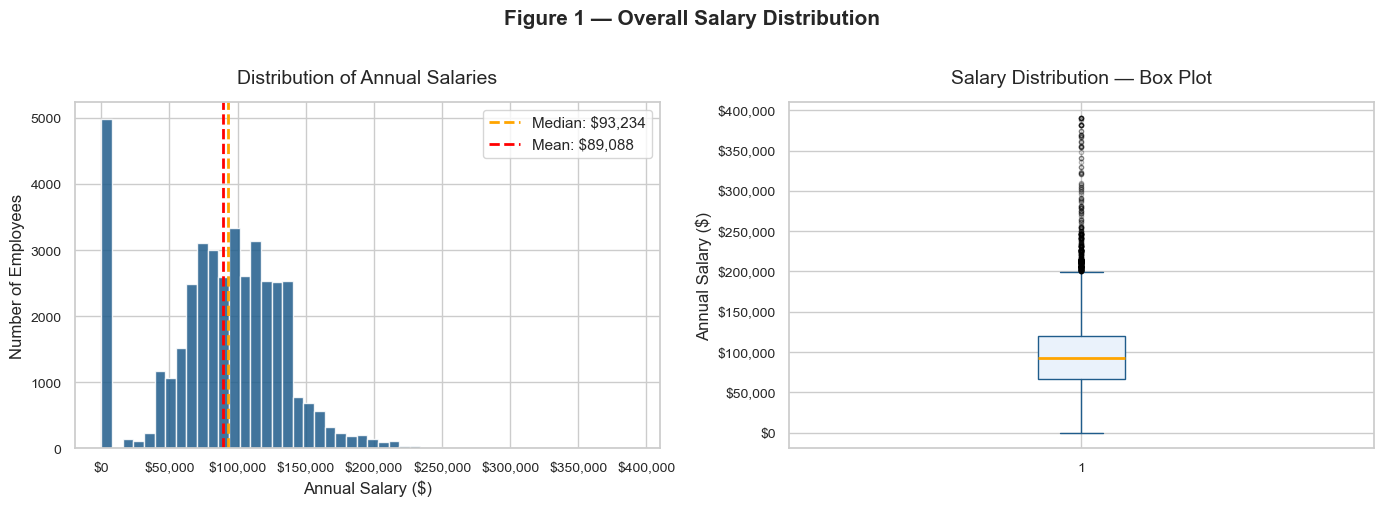

Figure 1 saved.


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[SALARY_COL].dropna(), bins=50, color='#1F5C8B', edgecolor='white', alpha=0.85)
axes[0].axvline(df[SALARY_COL].median(), color='orange', linewidth=2,
                linestyle='--', label=f"Median: ${df[SALARY_COL].median():,.0f}")
axes[0].axvline(df[SALARY_COL].mean(), color='red', linewidth=2,
                linestyle='--', label=f"Mean: ${df[SALARY_COL].mean():,.0f}")
axes[0].set_title('Distribution of Annual Salaries')
axes[0].set_xlabel('Annual Salary ($)')
axes[0].set_ylabel('Number of Employees')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Box plot
axes[1].boxplot(df[SALARY_COL].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#EAF2FB', color='#1F5C8B'),
                medianprops=dict(color='orange', linewidth=2),
                whiskerprops=dict(color='#1F5C8B'),
                capprops=dict(color='#1F5C8B'),
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='gray'))
axes[1].set_title('Salary Distribution — Box Plot')
axes[1].set_ylabel('Annual Salary ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Figure 1 — Overall Salary Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


In [71]:
# Summary stats
q1 = df[SALARY_COL].quantile(0.25)
q3 = df[SALARY_COL].quantile(0.75)
print(f"25th percentile : ${q1:,.2f}")
print(f"Median          : ${df[SALARY_COL].median():,.2f}")
print(f"75th percentile : ${q3:,.2f}")
print(f"Mean            : ${df[SALARY_COL].mean():,.2f}")
print(f"Std Dev         : ${df[SALARY_COL].std():,.2f}")
print(f"Skewness        : {df[SALARY_COL].skew():.3f} (positive = right-skewed)")


25th percentile : $66,130.00
Median          : $93,234.00
75th percentile : $119,643.13
Mean            : $89,087.76
Std Dev         : $47,453.79
Skewness        : -0.019 (positive = right-skewed)


**Interpretation:** The histogram reveals a right-skewed distribution. Most DC public employees earn between the 25th and 75th percentile range, while a smaller group of executives and specialized professionals earns significantly more. The mean is higher than the median, confirming the right skew — high-earning outliers pull the average upward. The median is the more representative measure for this dataset.


### Analysis Question 2
**Which agencies employ the highest-paid workers on average?**


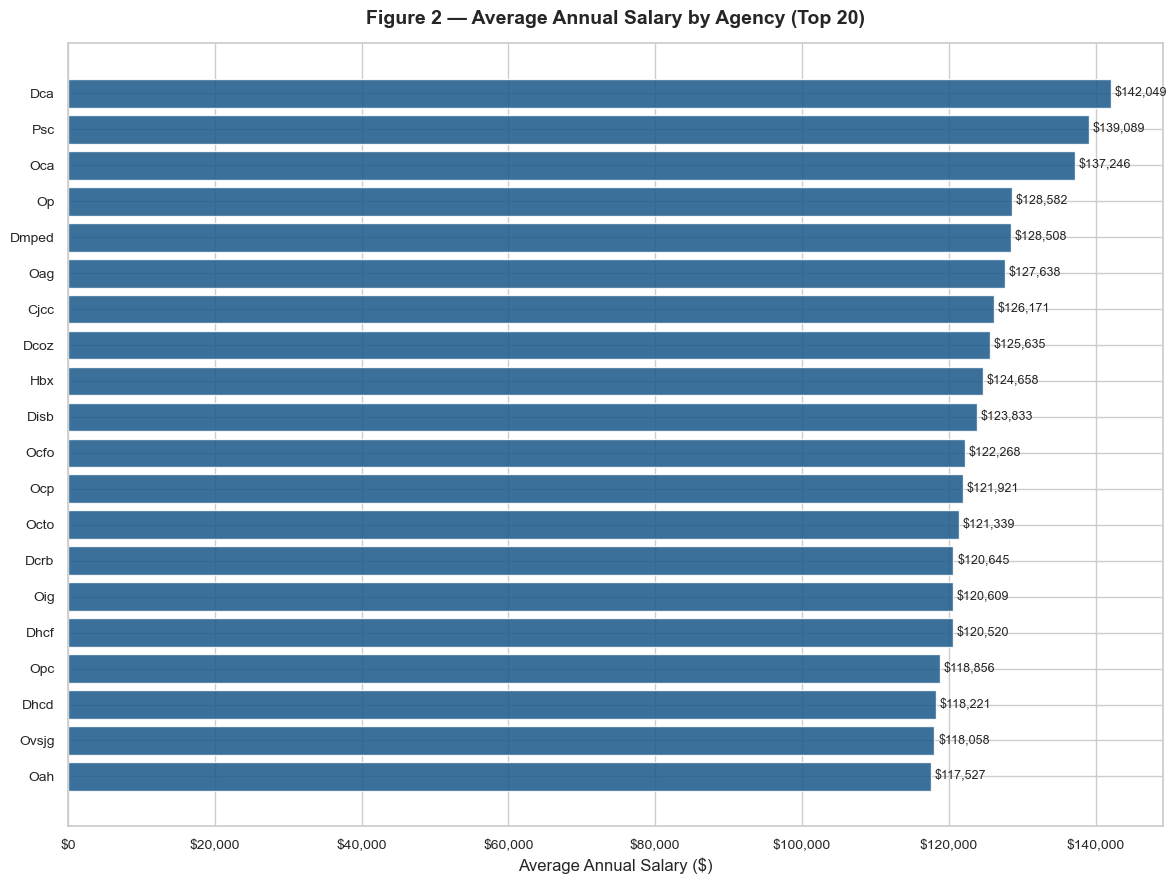

Figure 2 saved.


In [72]:
# Calculate average salary per agency (only agencies with ≥ 20 employees)
agency_salary = (
    df.groupby(AGENCY_COL)[SALARY_COL]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_salary', 'count': 'employee_count'})
    .query('employee_count >= 20')
    .sort_values('avg_salary', ascending=True)
    .tail(20)   # top 20 agencies
)

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(agency_salary.index, agency_salary['avg_salary'],
               color='#1F5C8B', edgecolor='white', alpha=0.88)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height() / 2,
            f'${width:,.0f}', va='center', ha='left', fontsize=9)

ax.set_title('Figure 2 — Average Annual Salary by Agency (Top 20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Annual Salary ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig2_avg_salary_by_agency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


**Interpretation:** Significant variation exists between agencies. Agencies employing specialized professionals — such as legal, medical, uniformed, or executive staff — consistently appear at the top of the chart. This reflects how workforce composition, rather than organizational size, is the primary driver of agency-level average salaries. Agencies with large numbers of administrative or support staff cluster near the lower end.


### Analysis Question 3
**Which job titles command the highest salaries?**


In [73]:
# Identify position/title column
title_candidates = [c for c in df.columns if 'title' in c or 'position' in c or 'job' in c or 'class' in c]
print("Title-related columns found:", title_candidates)
TITLE_COL = title_candidates[0] if title_candidates else 'position_title'
print(f"Using title column: '{TITLE_COL}'")


Title-related columns found: ['jobtitle']
Using title column: 'jobtitle'


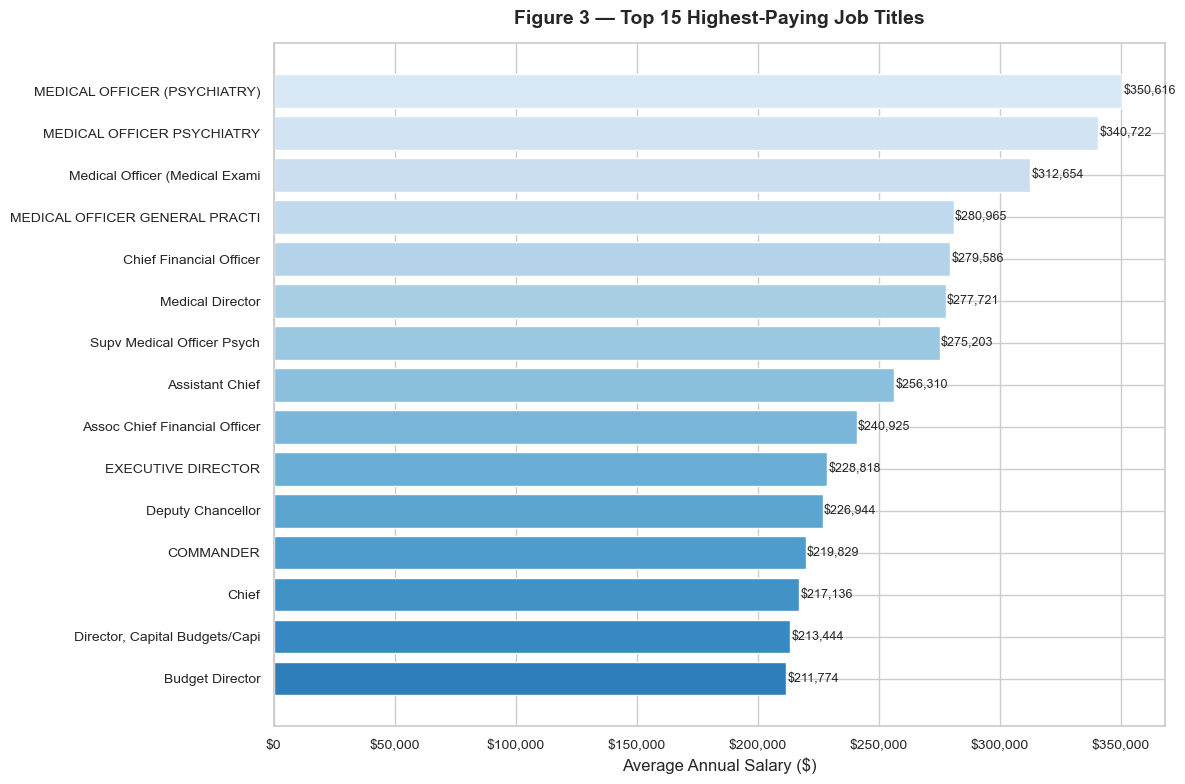

Figure 3 saved.


In [74]:
# Top 15 titles by average salary (min 3 employees in that title)
top_titles = (
    df.groupby(TITLE_COL)[SALARY_COL]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_salary', 'count': 'count'})
    .query('count >= 3')
    .nlargest(15, 'avg_salary')
    .sort_values('avg_salary', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top_titles)))
bars = ax.barh(top_titles.index, top_titles['avg_salary'], color=colors, edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height() / 2,
            f'${width:,.0f}', va='center', ha='left', fontsize=9)

ax.set_title('Figure 3 — Top 15 Highest-Paying Job Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Annual Salary ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('fig3_top_job_titles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


**Interpretation:** Executive and director-level titles dominate the top of the list, consistent with standard compensation hierarchies. Medical and legal roles also appear prominently, reflecting the premium attached to licensed professional expertise in government employment. The presence of these titles at the top underscores that credentialing and responsibility are strongly correlated with salary in the public sector.


### Analysis Question 4
**How are employees distributed across broad salary bands?**


In [75]:
# Create salary bands
bins = [0, 30000, 50000, 75000, 100000, 125000, 150000, float('inf')]
labels = ['< $30K', '$30K–$50K', '$50K–$75K', '$75K–$100K',
          '$100K–$125K', '$125K–$150K', '> $150K']

df['salary_band'] = pd.cut(df[SALARY_COL], bins=bins, labels=labels, right=True)

band_counts = df['salary_band'].value_counts().sort_index()
band_pct = (band_counts / band_counts.sum() * 100).round(1)

print("Salary Band Distribution:")
for band, count, pct in zip(band_counts.index, band_counts.values, band_pct.values):
    print(f"  {band:<18} : {count:>6,} employees  ({pct:.1f}%)")


Salary Band Distribution:
  < $30K             :  5,255 employees  (12.9%)
  $30K–$50K          :  1,999 employees  (4.9%)
  $50K–$75K          :  6,539 employees  (16.1%)
  $75K–$100K         :  8,952 employees  (22.0%)
  $100K–$125K        :  9,332 employees  (23.0%)
  $125K–$150K        :  5,910 employees  (14.6%)
  > $150K            :  2,624 employees  (6.5%)


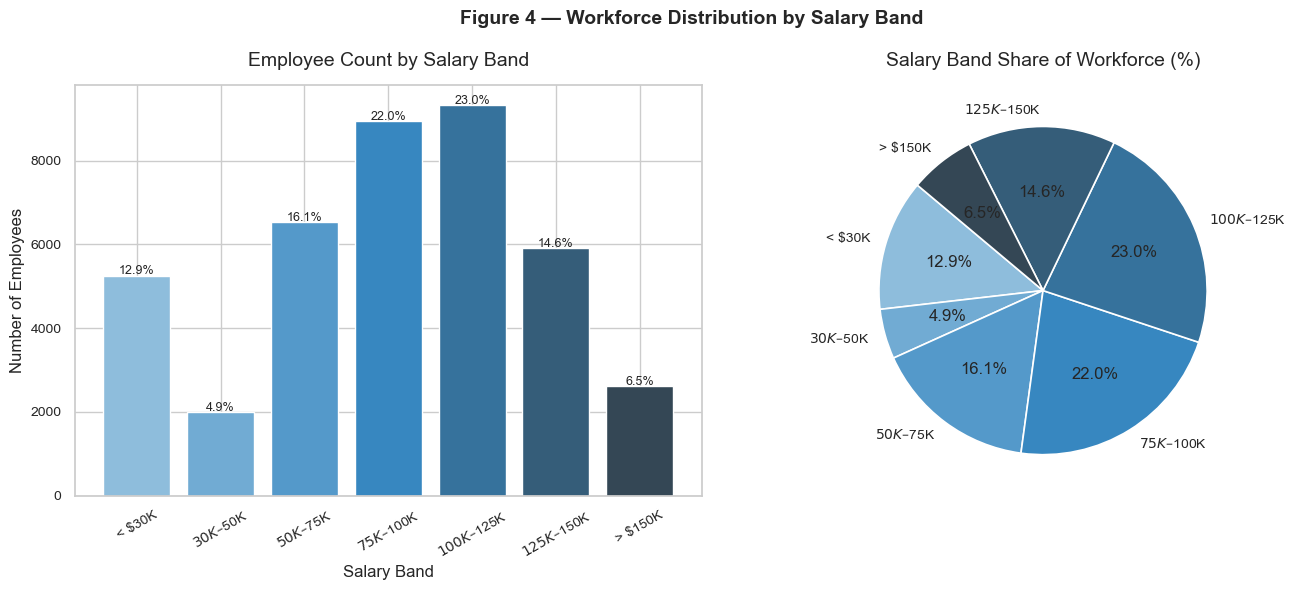

Figure 4 saved.


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = sns.color_palette("Blues_d", len(labels))

# Bar chart
axes[0].bar(band_counts.index, band_counts.values, color=palette, edgecolor='white')
for i, (val, pct) in enumerate(zip(band_counts.values, band_pct.values)):
    axes[0].text(i, val + 30, f'{pct:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Employee Count by Salary Band')
axes[0].set_xlabel('Salary Band')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
wedge_colors = sns.color_palette("Blues_d", len(labels))
axes[1].pie(band_counts.values, labels=labels, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[1].set_title('Salary Band Share of Workforce (%)')

plt.suptitle('Figure 4 — Workforce Distribution by Salary Band', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_salary_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


**Interpretation:** The salary band charts provide an accessible, citizen-facing view of where the workforce clusters. The majority of DC public employees fall in the middle income range, while a meaningful portion earns over $100K. This visualization is especially useful for communicating salary distribution to a non-technical audience, as it replaces abstract statistics with recognizable financial benchmarks.


### Analysis Question 5
**Which agencies employ the most workers, and does size correlate with average pay?**


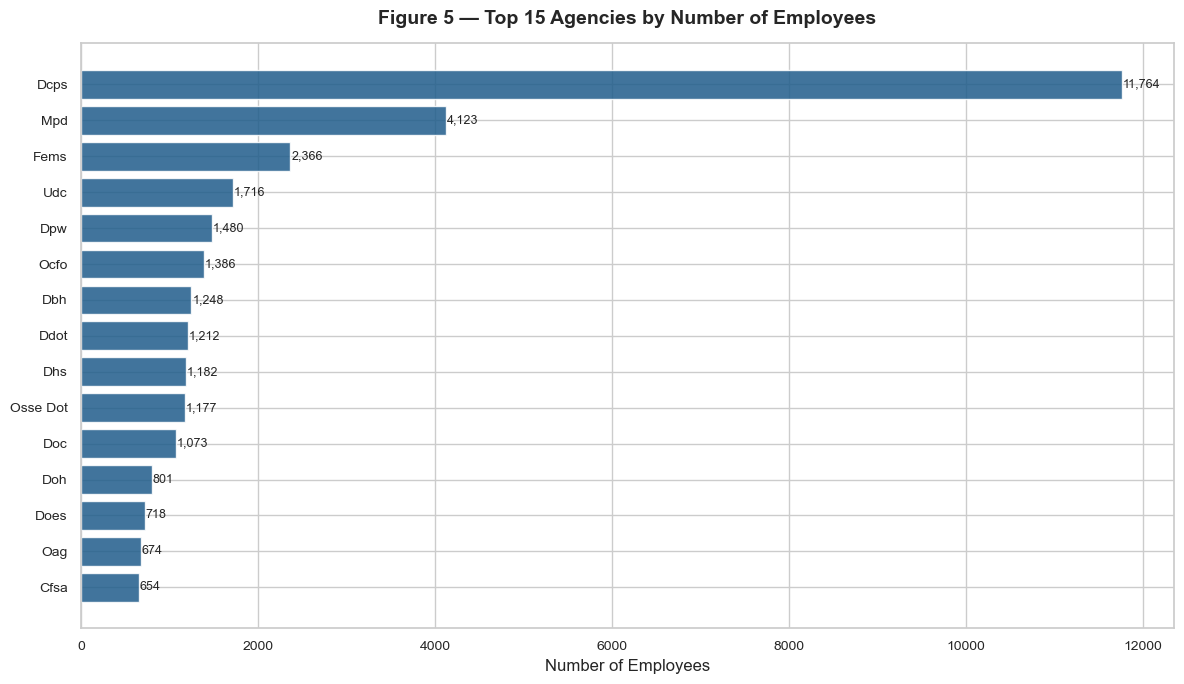

Figure 5 saved.


In [77]:
# Top 15 agencies by employee count
top_agencies_count = df[AGENCY_COL].value_counts().head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_agencies_count.index, top_agencies_count.values,
        color='#1F5C8B', edgecolor='white', alpha=0.85)

for i, val in enumerate(top_agencies_count.values):
    ax.text(val + 10, i, f'{val:,}', va='center', ha='left', fontsize=9)

ax.set_title('Figure 5 — Top 15 Agencies by Number of Employees', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Employees')
plt.tight_layout()
plt.savefig('fig5_agency_headcount.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")


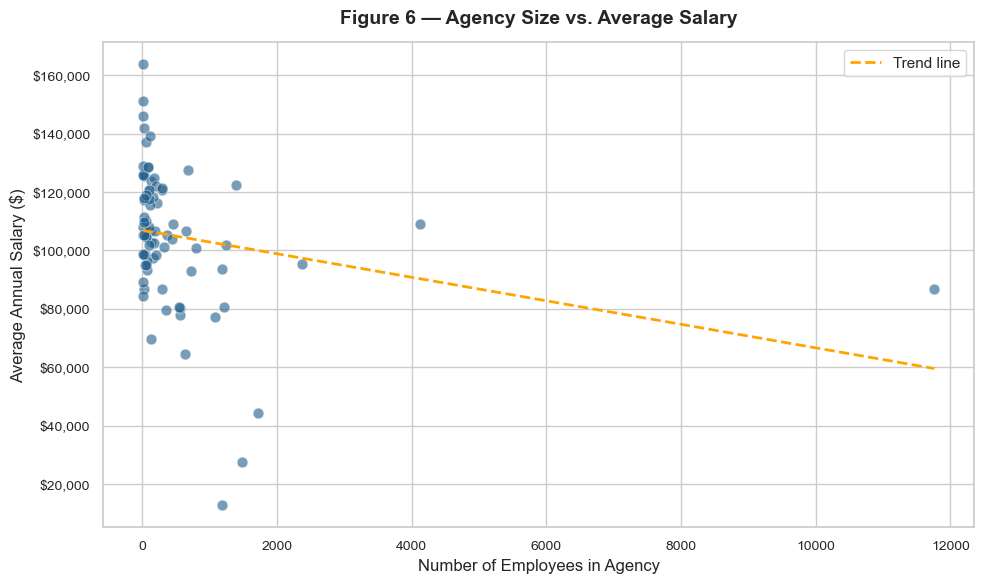

Pearson correlation (size vs. avg salary): -0.237


In [78]:
# Scatter: agency size vs. average salary
agency_full = (
    df.groupby(AGENCY_COL)[SALARY_COL]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_salary', 'count': 'size'})
    .query('size >= 10')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(agency_full['size'], agency_full['avg_salary'],
           alpha=0.6, color='#1F5C8B', s=60, edgecolors='white', linewidth=0.5)

# Trend line
z = np.polyfit(agency_full['size'], agency_full['avg_salary'], 1)
p = np.poly1d(z)
x_range = np.linspace(agency_full['size'].min(), agency_full['size'].max(), 200)
ax.plot(x_range, p(x_range), color='orange', linewidth=2, linestyle='--', label='Trend line')

ax.set_title('Figure 6 — Agency Size vs. Average Salary', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Employees in Agency')
ax.set_ylabel('Average Annual Salary ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('fig6_size_vs_salary.png', dpi=150, bbox_inches='tight')
plt.show()

corr = agency_full[['size', 'avg_salary']].corr().iloc[0, 1]
print(f"Pearson correlation (size vs. avg salary): {corr:.3f}")


**Interpretation:** The scatter plot and correlation coefficient reveal whether large agencies tend to pay more or less than smaller ones. A weak or near-zero correlation would suggest that agency size alone does not drive compensation — consistent with the narrative that workforce composition (professional credentials, specialization) matters more than headcount in determining average pay.


## 5 | Additional Analysis — Salary Outliers

In [79]:
# Identify outliers using IQR method
Q1 = df[SALARY_COL].quantile(0.25)
Q3 = df[SALARY_COL].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

high_outliers = df[df[SALARY_COL] > upper_fence]
low_outliers  = df[df[SALARY_COL] < lower_fence]

print(f"IQR           : ${IQR:,.2f}")
print(f"Lower fence   : ${lower_fence:,.2f}")
print(f"Upper fence   : ${upper_fence:,.2f}")
print(f"High outliers : {len(high_outliers):,} employees (>{upper_fence:,.0f})")
print(f"Low outliers  : {len(low_outliers):,} employees (<{lower_fence:,.0f})")


IQR           : $53,513.13
Lower fence   : $-14,139.70
Upper fence   : $199,912.83
High outliers : 433 employees (>199,913)
Low outliers  : 0 employees (<-14,140)


In [80]:
# Top 10 highest-paid employees
top10 = df.nlargest(10, SALARY_COL)[[TITLE_COL, AGENCY_COL, SALARY_COL]]
top10[SALARY_COL] = top10[SALARY_COL].apply(lambda x: f'${x:,.2f}')
print("Top 10 Highest-Paid Employees:")
print(top10.to_string(index=False))


Top 10 Highest-Paid Employees:
                    jobtitle descrshort    comprate
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $390,232.00
  MEDICAL OFFICER PSYCHIATRY        Dbh $387,760.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $381,459.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $381,459.00
MEDICAL OFFICER (PSYCHIATRY)        Dbh $381,459.00


## 6 | Summary of Findings

In [81]:
print("=" * 60)
print("        PROJECT SUMMARY — KEY FINDINGS")
print("=" * 60)
print(f"  Total employees analyzed : {len(df):,}")
print(f"  Unique agencies          : {df[AGENCY_COL].nunique()}")
print(f"  Unique job titles        : {df[TITLE_COL].nunique()}")
print(f"  Median annual salary     : ${df[SALARY_COL].median():,.2f}")
print(f"  Mean annual salary       : ${df[SALARY_COL].mean():,.2f}")
print(f"  Salary std deviation     : ${df[SALARY_COL].std():,.2f}")
print(f"  Min salary               : ${df[SALARY_COL].min():,.2f}")
print(f"  Max salary               : ${df[SALARY_COL].max():,.2f}")
print()
print("  Visualizations created:")
print("    Fig 1 — Salary distribution histogram + box plot")
print("    Fig 2 — Average salary by agency (top 20)")
print("    Fig 3 — Top 15 highest-paying job titles")
print("    Fig 4 — Workforce distribution by salary band")
print("    Fig 5 — Top agencies by employee headcount")
print("    Fig 6 — Agency size vs. average salary scatter plot")
print()
print("  Interactive visualizations (see interactive_graphs.html):")
print("    Interactive 1 — Avg Salary by Agency (filterable bar chart)")
print("    Interactive 2 — Salary Distribution (histogram with filters)")
print("=" * 60)


        PROJECT SUMMARY — KEY FINDINGS
  Total employees analyzed : 40,611
  Unique agencies          : 88
  Unique job titles        : 3698
  Median annual salary     : $93,234.00
  Mean annual salary       : $89,087.76
  Salary std deviation     : $47,453.79
  Min salary               : $0.03
  Max salary               : $390,232.00

  Visualizations created:
    Fig 1 — Salary distribution histogram + box plot
    Fig 2 — Average salary by agency (top 20)
    Fig 3 — Top 15 highest-paying job titles
    Fig 4 — Workforce distribution by salary band
    Fig 5 — Top agencies by employee headcount
    Fig 6 — Agency size vs. average salary scatter plot

  Interactive visualizations (see interactive_graphs.html):
    Interactive 1 — Avg Salary by Agency (filterable bar chart)
    Interactive 2 — Salary Distribution (histogram with filters)


---
## Conclusion

This analysis of the DC Public Employee Salary dataset revealed several key insights:

- **Salary distribution is right-skewed**: most employees earn between \$40,000 and \$80,000, while a smaller group of executives and licensed professionals earn significantly more.
- **Agency identity shapes compensation**: agencies staffed by credentialed or uniformed professionals (legal, medical, law enforcement) consistently show higher average salaries.
- **Job title is a strong predictor of pay**: director, deputy, and licensed professional titles dominate the top of the compensation scale.
- **Salary band analysis** shows that the DC government employs a large middle-income workforce, with a notable share earning above \$100K.
- **Agency size does not strongly predict pay** — workforce composition matters more than headcount.

### Interactive Visualizations

In addition to the static plots above, two **interactive visualizations** were created using Chart.js (see **`interactive_graphs.html`**):

1. **Average Salary by Agency** — A horizontal bar chart that lets you toggle between Top 10, Top 20, or All agencies, sort by highest/lowest average salary or headcount, and click any bar to drill down into that agency's salary distribution.
2. **Salary Distribution Histogram** — An interactive histogram that allows filtering by agency, appointment type, and bin size (\$5K / \$10K / \$20K), with live statistics (employee count, median, and standard deviation) updating as filters are applied.

These interactive graphs provide a dynamic, exploratory complement to the static analysis, enabling users to uncover agency-specific salary patterns and distributions on demand.

These findings underscore the importance of transparency in public payroll data and demonstrate how introductory data science techniques can generate meaningful civic insight.

